In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Import files

In [ ]:
data_dir = Path("../data/TNG300-1/output/groups_099")

files = sorted(data_dir.glob("groupcat-099.*.hdf5"))

print(f"Found {len(files)} files")
print(files[:5])
print(files[-5:])

Found 600 files
[WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.0.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.1.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.10.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.100.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.101.hdf5')]
[WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.95.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.96.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.97.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.98.hdf5'), WindowsPath('../data/TNG300-1/output/groups_099/fof_subhalo_tab_099.99.hdf5')]


In [ ]:
all_fdm = []

for file in files:
    with h5py.File(file, "r") as f:
        mass = f["Subhalo"]["SubhaloMassInRadType"][:]
        dm = mass[:, 1]
        total = np.sum(mass, axis=1)

        fdm = np.divide(
            dm,
            total,
            out=np.full_like(dm, np.nan, dtype=float),
            where=total > 0
        )

        all_fdm.append(fdm)

fdm = np.concatenate(all_fdm)

print("Number of subhalos:", len(fdm))
print("Finite f_DM values:", np.isfinite(fdm).sum())

KeyError: "Unable to synchronously open object (object 'SubhaloMassInRadType' doesn't exist)"

Get files and calculate $f_{dm}$

In [ ]:
catalog = pd.DataFrame({
    "SubhaloID": np.arange(len(fdm)),
    "f_DM_2Rh": fdm
})

catalog.head()

,SubhaloID,f_DM_2Rh
0,0,0.855604
1,1,0.870916
2,2,0.735097
3,3,0.814691
4,4,0.790187


In [ ]:
catalog = pd.DataFrame({
    "SubhaloID": np.arange(len(fdm)),
    "f_DM_2Rh": fdm
})

catalog.head()

,SubhaloID,f_DM_2Rh
0,0,0.855604
1,1,0.870916
2,2,0.735097
3,3,0.814691
4,4,0.790187


Create catalogue

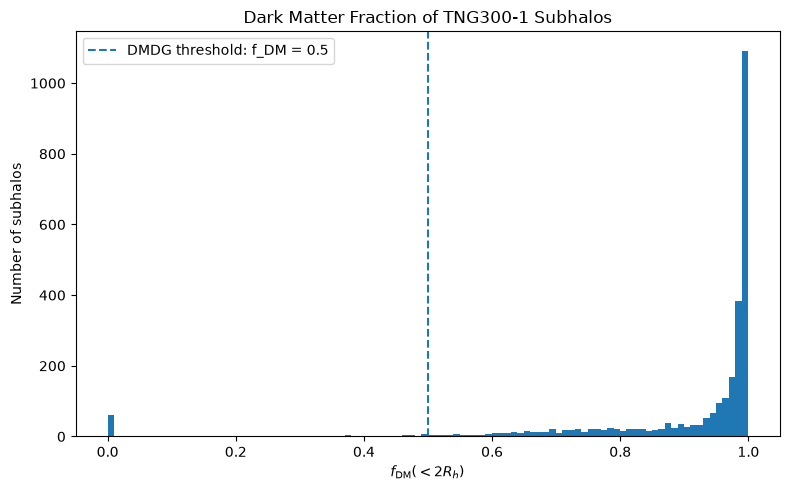

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    catalog["f_DM_2Rh"].dropna(),
    bins=100
)

plt.axvline(
    0.5,
    linestyle="--",
    label="DMDG threshold: f_DM = 0.5"
)

plt.xlabel(r"$f_{\rm DM}(<2R_h)$")
plt.ylabel("Number of subhalos")
plt.title("Dark Matter Fraction of TNG300-1 Subhalos")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
dmdgs = catalog[
    catalog["f_DM_2Rh"] < 0.5
]

print("DMDG candidates:", len(dmdgs))
print("Total:", len(catalog))
print("Fraction:", len(dmdgs) / len(catalog))

DMDG candidates: 91
Total: 11748
Fraction: 0.0077459993190330265
